#**NUMPY**
### SECTION 1: WHY NUMPY EXISTS & THE SPEED GAP

In standard Python:  
A list is an array of POINTERS to boxed objects scattered across heap memory.  
In NumPy: An ndarray is a CONTIGUOUS block of raw, uniform primitive C-types in memory.  
This enables CPU cache locality, SIMD vectorisation, and parallel processing.

In [1]:
import numpy as np

print(f"NumPy Version: {np.__version__}")

# Benchmark: Python loop vs. Vectorised NumPy operation (1,000,000 elements)
size = 1_000_000
py_list = list(range(size))
np_arr = np.arange(size)
print(np_arr)

NumPy Version: 2.1.3
[     0      1      2 ... 999997 999998 999999]


### SECTION 2: ARRAY CREATION & ATTRIBUTES

In [2]:
# Seed for reproducibility
np.random.seed(42)

# 1. Creation from lists
a1 = np.array([1, 2, 3, 4], dtype=np.float32)

# 2. Structural initialisations
zeros = np.zeros((2, 3))               # 2x3 matrix of 0.0
ones = np.ones((2, 2), dtype=int)      # 2x2 matrix of 1s
full = np.full((2, 3), fill_value=7)   # 2x3 matrix filled with 7
identity = np.eye(3)                   # 3x3 Identity matrix

# 3. Range-based creation
seq_step = np.arange(0, 10, 2)         # start, stop (exclusive), step -> [0, 2, 4, 6, 8]
seq_lin = np.linspace(0, 1, 5)         # start, stop (inclusive), num points -> [0., 0.25, 0.5, 0.75, 1.]

# 4. Random arrays
rand_uniform = np.random.rand(2, 3)    # Uniform [0, 1)
rand_normal = np.random.randn(2, 3)    # Standard normal (mean 0, std 1)
rand_int = np.random.randint(1, 10, size=(2, 3)) # Discrete integers [low, high)

print("Array:\n", rand_int)
print("Attributes:")
print(f" - shape (dimensions):        {rand_int.shape}")
print(f" - ndim  (num of axes):       {rand_int.ndim}")
print(f" - size  (total elements):    {rand_int.size}")
print(f" - dtype (element data type): {rand_int.dtype}")

Array:
 [[6 9 1]
 [3 7 4]]
Attributes:
 - shape (dimensions):        (2, 3)
 - ndim  (num of axes):       2
 - size  (total elements):    6
 - dtype (element data type): int64


### SECTION 3: INDEXING, SLICING, & THE "VIEW VS COPY" GOTCHA

In [3]:
mat = np.arange(1, 13).reshape(3, 4)
print("Original Matrix:\n", mat)

# Basic 2D Slicing: [rows, cols]
sub_mat = mat[0:2, 1:3]
print("\nSlice [0:2, 1:3]:\n", sub_mat)

# --- CRITICAL GOTCHA: Slices create VIEWS (shared memory), NOT deep copies! ---
sub_mat[0, 0] = 999
print("\nAfter modifying sub_mat[0, 0] to 999:")
print("Original Matrix is mutated!:\n", mat)

# To prevent mutating the original, explicitly use .copy()
mat_copy = mat[0:2, 1:3].copy()
mat_copy[0, 0] = -1
print("\nModifying an explicit copy does NOT mutate original:")
print("Original mat[0, 1] remains:", mat[0, 1])

Original Matrix:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Slice [0:2, 1:3]:
 [[2 3]
 [6 7]]

After modifying sub_mat[0, 0] to 999:
Original Matrix is mutated!:
 [[  1 999   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]

Modifying an explicit copy does NOT mutate original:
Original mat[0, 1] remains: 999


### SECTION 4: BOOLEAN MASKING & FANCY INDEXING


In [4]:
arr = np.array([10, 25, 30, 45, 50, 65])

# 1. Boolean Masking (filtering)
mask = arr > 30
print("Boolean Mask (arr > 30):", mask)
print("Filtered Elements:       ", arr[mask])

# In-place condition replacement
arr[arr > 40] = 0
print("After replacing values > 40 with 0:", arr)

# 2. Fancy Indexing (integer array indexing - always returns a COPY)
data = np.arange(10, 100, 10).reshape(3, 3)
print("\nData:\n", data)
rows = np.array([0, 2])
cols = np.array([1, 2])
print("Selected elements (0,1) and (2,2):", data[rows, cols])

Boolean Mask (arr > 30): [False False False  True  True  True]
Filtered Elements:        [45 50 65]
After replacing values > 40 with 0: [10 25 30  0  0  0]

Data:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]
Selected elements (0,1) and (2,2): [20 90]


### SECTION 5: SHAPE MANIPULATION & EXPANSIONS

In [5]:
arr = np.arange(6) # [0, 1, 2, 3, 4, 5]

# 1. Reshape
r_arr = arr.reshape(2, 3)
print("Reshaped (2, 3):\n", r_arr)

# 2. Ravel (View where possible) vs Flatten (Always creates a Copy)
rav = r_arr.ravel()
flat = r_arr.flatten()

# 3. Transpose
print("Transposed (3, 2):\n", r_arr.T)

# 4. Dimension Expansion (used frequently in deep learning and broadcasting)
v = np.array([1, 2, 3]) # shape: (3,)
v_col1 = np.expand_dims(v, axis=1) # shape: (3, 1)
v_col2 = v[:, np.newaxis]          # shape: (3, 1)
print("Vector expanded to column shape:", v_col1.shape)

Reshaped (2, 3):
 [[0 1 2]
 [3 4 5]]
Transposed (3, 2):
 [[0 3]
 [1 4]
 [2 5]]
Vector expanded to column shape: (3, 1)


### SECTION 7: AGGREGATIONS & THE AXIS PARAMETER

In [6]:
# Visual rule for 2D:
# axis=0: Collapse rows (move down vertically -> compute for each column)
# axis=1: Collapse columns (move across horizontally -> compute for each row)

X = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

print("Data:\n", X)
print("Sum Total:           ", np.sum(X))
print("Sum axis=0 (per col):", np.sum(X, axis=0))
print("Sum axis=1 (per row):", np.sum(X, axis=1))
print("Mean per column:     ", np.mean(X, axis=0))
print("Std per row:         ", np.std(X, axis=1))
print("Index of max overall:", np.argmax(X))
print("Index of max per col:", np.argmax(X, axis=0))

Data:
 [[10 20 30]
 [40 50 60]]
Sum Total:            210
Sum axis=0 (per col): [50 70 90]
Sum axis=1 (per row): [ 60 150]
Mean per column:      [25. 35. 45.]
Std per row:          [8.16496581 8.16496581]
Index of max overall: 5
Index of max per col: [1 1 1]


In [7]:
# LIVE CODE BENCHMARK: COLUMN-WISE NORMALISATION (Z-Score Standardisation)
# Formula: Z = (X - mean) / std

# Matrix: 10,000 rows (samples), 100 columns (features)
N_ROWS, N_COLS = 10_000, 100
dataset = np.random.randn(N_ROWS, N_COLS) * 5 + 20

def python_loop_normalise(mat):
    """Normalises each column using standard nested Python loops."""
    rows, cols = mat.shape
    out = np.empty((rows, cols))
    for j in range(cols):
        # Calculate mean & std for column j
        col_sum = 0.0
        for i in range(rows):
            col_sum += mat[i, j]
        col_mean = col_sum / rows

        variance_sum = 0.0
        for i in range(rows):
            variance_sum += (mat[i, j] - col_mean) ** 2
        col_std = (variance_sum / rows) ** 0.5

        # Normalise column
        for i in range(rows):
            out[i, j] = (mat[i, j] - col_mean) / col_std
    return out

def vectorised_normalise(mat):
    """Normalises all columns simultaneously via axis aggregation & broadcasting."""
    mean = np.mean(mat, axis=0) # shape: (100,)
    std = np.std(mat, axis=0)   # shape: (100,)
    return (mat - mean) / std   # (10000, 100) - (100,) -> broadcasted!

# Validate equivalence
norm_loop = python_loop_normalise(dataset[:100, :10])
norm_vec = vectorised_normalise(dataset[:100, :10])
assert np.allclose(norm_loop, norm_vec)
print("Outputs match perfectly!\n")

print("--- Benchmark: Normalising (10,000 x 100) Matrix ---")
print("1. Nested Python Loops:")
%timeit python_loop_normalise(dataset)

print("2. Vectorised Broadcasting:")
%timeit vectorised_normalise(dataset)

Outputs match perfectly!

--- Benchmark: Normalising (10,000 x 100) Matrix ---
1. Nested Python Loops:
779 ms ± 41.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2. Vectorised Broadcasting:
5.41 ms ± 74 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### SECTION 8: BROADCASTING

In [8]:
a = np.array([1, 2, 3])
b = 2
print("Array + Scalar (Broadcasting):")
print(a + b)

A = np.array([[1, 2, 3], [4, 5, 6]]) # Shape (2, 3)
b = np.array([10, 20, 30])           # Shape (3,)
print("\nMatrix + 1D Array (Broadcasting - adds to each row):")
print(A + b)

# Example of adding a column vector to a matrix
C = np.arange(6).reshape(3, 2)
D = np.array([100, 200, 300]).reshape(3, 1) # Column vector, shape (3, 1)
print("\nMatrix + Column Vector (Broadcasting - adds to each column):\n", C + D)

Array + Scalar (Broadcasting):
[3 4 5]

Matrix + 1D Array (Broadcasting - adds to each row):
[[11 22 33]
 [14 25 36]]

Matrix + Column Vector (Broadcasting - adds to each column):
 [[100 101]
 [202 203]
 [304 305]]


### SECTION 9: UNIVERSAL FUNCTIONS (UFUNCS)

In [12]:
x = np.array([-1, 0, 1, 2, 3])

# Element-wise operations
print("Original array:", x)
print("Absolute values:", np.abs(x))
print("Square root:", np.sqrt(x.astype(float))) # Need float for sqrt of negative numbers
print("Exponential:", np.exp(x))

# Trigonometric functions
angles = np.array([0, np.pi/2, np.pi])
print("\nAngles:", angles)
print("Sine:", np.sin(angles))

# Comparison ufuncs
a = np.array([1, 5, 3])
b = np.array([2, 4, 3])
print("\nArray a:", a)
print("Array b:", b)
print("a > b (element-wise):", np.greater(a, b))
print("Maximum (element-wise):", np.maximum(a, b))

Original array: [-1  0  1  2  3]
Absolute values: [1 0 1 2 3]
Square root: [       nan 0.         1.         1.41421356 1.73205081]
Exponential: [ 0.36787944  1.          2.71828183  7.3890561  20.08553692]

Angles: [0.         1.57079633 3.14159265]
Sine: [0.0000000e+00 1.0000000e+00 1.2246468e-16]

Array a: [1 5 3]
Array b: [2 4 3]
a > b (element-wise): [False  True False]
Maximum (element-wise): [2 5 3]


/tmp/ipykernel_1431/1571123181.py:6: RuntimeWarning: invalid value encountered in sqrt
  print("Square root:", np.sqrt(x.astype(float))) # Need float for sqrt of negative numbers


### SECTION 10: 12 STUDENT EXERCISES

In [15]:
# --- Exercise 1 ---
# Create a 1D array of 20 evenly spaced values between 5 and 50 (inclusive).
# Hint: np.linspace
# YOUR CODE HERE:
ex1 = np.linspace(5, 50, 20)

# --- Exercise 2 ---
# Create a 4x4 matrix where border elements are 1 and inside elements are 0.
# YOUR CODE HERE:
ex2 = np.ones((4, 4))
ex2[1:-1, 1:-1] = 0

# --- Exercise 3 ---
# Create an array of random integers between 10 and 100 of shape (5, 5).
# Replace all even values with -1 without modifying the original array (return a new array).
# Hint: np.where
# YOUR CODE HERE:
orig = np.random.randint(10, 100, size=(5, 5))
ex3 = np.where(orig % 2 == 0, -1, orig)

# --- Exercise 4 ---
# Given a 1D array, extract elements that are greater than 20 AND divisible by 3.
# Hint: bitwise operator &
ex4_arr = np.array([12, 21, 24, 30, 5, 18, 45, 9, 33])
# YOUR CODE HERE:
ex4 = ex4_arr[(ex4_arr > 20) & (ex4_arr % 3 == 0)]

# --- Exercise 5 ---
# Given a 2D array, reverse its rows (top row becomes bottom row) using slicing.
ex5_mat = np.arange(16).reshape(4, 4)
# YOUR CODE HERE:
ex5 = ex5_mat[::-1, :]

# --- Exercise 6 ---
# Given an array of shape (6, 1) and an array of shape (1, 4), perform an addition
# that outputs an array of shape (6, 4).
# YOUR CODE HERE:
u = np.arange(6).reshape(6, 1)
v = np.arange(4).reshape(1, 4)
ex6 = u + v

# --- Exercise 7 ---
# Given a 2D array (5x3), subtract the mean of each column from the respective column.
# YOUR CODE HERE:
mat_ex7 = np.random.rand(5, 3)
ex7 = mat_ex7 - np.mean(mat_ex7, axis=0)

# --- Exercise 8 ---
# Given a 2D array (4x5), subtract the mean of each row from the respective row.
# Hint: keepdims=True or expand_dims
# YOUR CODE HERE:
mat_ex8 = np.random.rand(4, 5)
ex8 = mat_ex8 - np.mean(mat_ex8, axis=1, keepdims=True)

# --- Exercise 9 ---
# Find the row index of the maximum value in each column of a 2D array.
# YOUR CODE HERE:
mat_ex9 = np.array([[10, 50, 30], [40, 20, 90], [15, 80, 25]])
ex9 = np.argmax(mat_ex9, axis=0)

# --- Exercise 10 ---
# Stack two 1D arrays of length 4 as columns into a 2D array of shape (4, 2).
# Hint: np.column_stack or np.vstack with transpose
# YOUR CODE HERE:
c1 = np.array([1, 2, 3, 4])
c2 = np.array([5, 6, 7, 8])
ex10 = np.column_stack((c1, c2))

# --- Exercise 11 ---
# Replace all NaN values in a given 1D float array with the mean of non-NaN values.
# Hint: np.isnan(), np.nanmean()
ex11_arr = np.array([1.0, 2.0, np.nan, 4.0, np.nan, 6.0])
# YOUR CODE HERE:
mean_val = np.nanmean(ex11_arr)
ex11 = ex11_arr.copy()
ex11[np.isnan(ex11)] = mean_val

# --- Exercise 12 ---
# Min-Max Feature Scaling: Normalise a 2D matrix column-wise so all values lie in [0, 1].
# Formula: (X - min) / (max - min)
# YOUR CODE HERE:
X_raw = np.random.randint(1, 100, size=(6, 3)).astype(float)
col_min = np.min(X_raw, axis=0)
col_max = np.max(X_raw, axis=0)
ex12 = (X_raw - col_min) / (col_max - col_min)

print("All 12 exercises executed successfully!")
print(ex1)
print('\n',ex2)
print('\n',ex3)
print('\n',ex4)
print('\n',ex5)
print('\n',ex6)
print('\n',ex6)
print('\n',ex7)
print('\n',ex8)
print('\n',ex9)
print('\n',ex10)
print('\n',ex11)
print('\n',ex12)

All 12 exercises executed successfully!
[ 5.          7.36842105  9.73684211 12.10526316 14.47368421 16.84210526
 19.21052632 21.57894737 23.94736842 26.31578947 28.68421053 31.05263158
 33.42105263 35.78947368 38.15789474 40.52631579 42.89473684 45.26315789
 47.63157895 50.        ]

 [[1. 1. 1. 1.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]

 [[-1 -1 -1 57 -1]
 [15 25 61 -1 49]
 [-1 -1 77 -1 -1]
 [-1 91 -1 -1 57]
 [-1 27 45 -1 -1]]

 [21 24 30 45 33]

 [[12 13 14 15]
 [ 8  9 10 11]
 [ 4  5  6  7]
 [ 0  1  2  3]]

 [[0 1 2 3]
 [1 2 3 4]
 [2 3 4 5]
 [3 4 5 6]
 [4 5 6 7]
 [5 6 7 8]]

 [[0 1 2 3]
 [1 2 3 4]
 [2 3 4 5]
 [3 4 5 6]
 [4 5 6 7]
 [5 6 7 8]]

 [[-0.19176898  0.19425197 -0.23710469]
 [ 0.14276946 -0.07303985 -0.15793838]
 [-0.01400405 -0.17040588 -0.20391062]
 [ 0.32373055  0.14574374  0.20783162]
 [-0.26072697 -0.09654998  0.39112207]]

 [[ 0.08466878 -0.08096078  0.17258477 -0.14187394 -0.03441882]
 [ 0.19095724 -0.3028291  -0.07971605  0.23282761 -0.0412397 ]
 [-0.29287526

#**PANDAS**

In [16]:
# CELL 0: SETUP & DATASET GENERATION (retail_sales.csv)
# Run this cell first to generate the dataset directly inside Google Colab!

import numpy as np
import pandas as pd

# Create a realistic retail sales dataset
np.random.seed(42)
n_rows = 150

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty', 'Books']
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Miami']
payment_methods = ['Credit Card', 'Debit Card', 'Cash', 'UPI', 'PayPal']
genders = ['Male', 'Female', 'Other']

dates = pd.date_range(start='2024-01-01', end='2024-06-30', periods=n_rows).strftime('%Y-%m-%d')
order_ids = [f"ORD{1000 + i}" for i in range(n_rows)]
customer_ids = [f"CUST{np.random.randint(100, 160)}" for _ in range(n_rows)]
ages = np.random.randint(18, 65, size=n_rows)
gender_col = np.random.choice(genders, size=n_rows, p=[0.48, 0.48, 0.04])
cat_col = np.random.choice(categories, size=n_rows)
qty_col = np.random.randint(1, 6, size=n_rows)
unit_prices = np.random.choice([15.0, 25.5, 49.99, 89.0, 120.0, 299.99, 450.0, 899.0], size=n_rows)
total_amounts = np.round(qty_col * unit_prices, 2)
payments = np.random.choice(payment_methods, size=n_rows)
city_col = np.random.choice(cities, size=n_rows)

raw_df = pd.DataFrame({
    'Order_ID': order_ids,
    'Date': dates,
    'Customer_ID': customer_ids,
    'Gender': gender_col,
    'Age': ages,
    'Category': cat_col,
    'Quantity': qty_col,
    'Unit_Price': unit_prices,
    'Total_Amount': total_amounts,
    'Payment_Method': payments,
    'City': city_col
})

# Inject a few missing values & sentinel strings to demonstrate cleaning
raw_df.loc[10, 'Age'] = np.nan
raw_df.loc[25, 'Payment_Method'] = "MISSING"

raw_df.to_csv("retail_sales.csv", index=False)
print("`retail_sales.csv` successfully created on disk!")

`retail_sales.csv` successfully created on disk!


### SECTION 1: SERIES VS DATAFRAME & INDEX AS A FIRST-CLASS CITIZEN

In [18]:
# 1. Series: 1D labeled homogeneous array
s = pd.Series([100, 250, 375], index=['store_A', 'store_B', 'store_C'], name="Revenue")
print("--- Pandas Series ---")
print(s)
print(f"Index: {s.index}, Values: {s.values}\n")

# 2. DataFrame: 2D labeled tabular data structure (Collection of aligned Series sharing an Index)
df_toy = pd.DataFrame({
    'Revenue': [100, 250, 375],
    'Expenses': [60, 140, 200]
}, index=['store_A', 'store_B', 'store_C'])

print("--- Pandas DataFrame ---")
print(df_toy)
print(f"Row Index: {df_toy.index.tolist()} | Columns: {df_toy.columns.tolist()}")

# Index Alignment Concept:
# When performing operations between Series, Pandas matches by INDEX LABEL, not position.
bonus = pd.Series([10, 20], index=['store_B', 'store_A'])
print("\nAutomatic Label Alignment (Revenue + Bonus):")
print(df_toy['Revenue'] + bonus) # Notice store_A got 10 and store_B got 20!

--- Pandas Series ---
store_A    100
store_B    250
store_C    375
Name: Revenue, dtype: int64
Index: Index(['store_A', 'store_B', 'store_C'], dtype='object'), Values: [100 250 375]

--- Pandas DataFrame ---
         Revenue  Expenses
store_A      100        60
store_B      250       140
store_C      375       200
Row Index: ['store_A', 'store_B', 'store_C'] | Columns: ['Revenue', 'Expenses']

Automatic Label Alignment (Revenue + Bonus):
store_A    120.0
store_B    260.0
store_C      NaN
dtype: float64


### SECTION 2: CREATING DATAFRAMES FROM PYTHON & NUMPY STRUCTURES

In [19]:
# 1. From Dictionary of Lists/Arrays
df_from_dict = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Keyboard'],
    'Stock': [15, 120, 45]
})

# 2. From List of Dictionaries (Row-oriented)
df_from_records = pd.DataFrame([
    {'Product': 'Monitor', 'Stock': 28},
    {'Product': 'Desk', 'Stock': 10}
])

# 3. From a 2D NumPy Array
np_matrix = np.random.randint(10, 99, size=(3, 3))
df_from_numpy = pd.DataFrame(
    data=np_matrix,
    index=['Row_1', 'Row_2', 'Row_3'],
    columns=['Col_A', 'Col_B', 'Col_C']
)
print("DataFrame from NumPy:\n", df_from_numpy)

DataFrame from NumPy:
        Col_A  Col_B  Col_C
Row_1     81     63     76
Row_2     60     17     43
Row_3     44     97     87


### SECTION 3: READING DATA (read_csv, read_excel, read_json)
 pd.read_csv key parameters:
 - sep: delimiter (default ',')
 - header: row number to use as column names (default 0)
 - names: custom list of column names to override
 - usecols: list of column names or indices to load (saves memory)
 - nrows: number of rows to read from top
 - na_values: additional strings to recognize as NaN/null
 - parse_dates: list of columns to convert to datetime

In [20]:
retail_df = pd.read_csv(
    'retail_sales.csv',
    sep=',',
    usecols=['Order_ID', 'Date', 'Customer_ID', 'Gender', 'Age', 'Category',
             'Quantity', 'Unit_Price', 'Total_Amount', 'Payment_Method', 'City'],
    na_values=['MISSING', 'N/A', 'null'],
    parse_dates=['Date']
)

print(f"Loaded {retail_df.shape[0]} rows and {retail_df.shape[1]} columns.\n")

# Syntax references for other formats:
# df_excel = pd.read_excel('file.xlsx', sheet_name='Sheet1')
# df_json  = pd.read_json('file.json')

Loaded 150 rows and 11 columns.



### SECTION 4: FIRST-LOOK PROFILING METHODS (Updated for Pandas 2.0+)

In [21]:
print("1. First 3 rows (.head):")
display(retail_df.head(3))

print("\n2. Dimensions (.shape):", retail_df.shape)
print("3. Data types (.dtypes):\n", retail_df.dtypes)

print("\n4. Structural summary (.info):")
retail_df.info()

print("\n5. Statistical distribution (.describe):")
display(retail_df.describe(include='all'))

print("\n6. Unique counts per column (.nunique):")
print(retail_df.nunique())

print("\n7. Frequency counts for Category (.value_counts):")
print(retail_df['Category'].value_counts(normalize=False))

1. First 3 rows (.head):


,Order_ID,Date,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Total_Amount,Payment_Method,City
0,ORD1000,2024-01-01,CUST138,Female,50.0,Electronics,4,49.99,199.96,Cash,Miami
1,ORD1001,2024-01-02,CUST151,Female,40.0,Books,4,450.00,1800.00,Cash,Miami
2,ORD1002,2024-01-03,CUST128,Male,41.0,Clothing,3,299.99,899.97,Credit Card,Chicago



2. Dimensions (.shape): (150, 11)
3. Data types (.dtypes):
 Order_ID                  object
Date              datetime64[ns]
Customer_ID               object
Gender                    object
Age                      float64
Category                  object
Quantity                   int64
Unit_Price               float64
Total_Amount             float64
Payment_Method            object
City                      object
dtype: object

4. Structural summary (.info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        150 non-null    object        
 1   Date            150 non-null    datetime64[ns]
 2   Customer_ID     150 non-null    object        
 3   Gender          150 non-null    object        
 4   Age             149 non-null    float64       
 5   Category        150 non-null    object        
 6   Quan

,Order_ID,Date,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Total_Amount,Payment_Method,City
count,150,150,150,150,149.000000,150,150.000000,150.000000,150.000000,149,150
unique,150,NaN,56,3,NaN,5,NaN,NaN,NaN,5,5
top,ORD1000,NaN,CUST159,Female,NaN,Books,NaN,NaN,NaN,Credit Card,Chicago
freq,1,NaN,8,80,NaN,35,NaN,NaN,NaN,36,32
mean,NaN,2024-03-31 00:09:36,NaN,NaN,40.610738,NaN,3.080000,242.463933,743.896133,NaN,NaN
min,NaN,2024-01-01 00:00:00,NaN,NaN,18.000000,NaN,1.000000,15.000000,15.000000,NaN,NaN
25%,NaN,2024-02-14 12:00:00,NaN,NaN,29.000000,NaN,2.000000,25.500000,91.745000,NaN,NaN
50%,NaN,2024-03-31 00:00:00,NaN,NaN,43.000000,NaN,3.000000,104.500000,299.990000,NaN,NaN
75%,NaN,2024-05-15 12:00:00,NaN,NaN,52.000000,NaN,4.750000,412.497500,899.727500,NaN,NaN
max,NaN,2024-06-30 00:00:00,NaN,NaN,64.000000,NaN,5.000000,899.000000,4495.000000,NaN,NaN



6. Unique counts per column (.nunique):
Order_ID          150
Date              150
Customer_ID        56
Gender              3
Age                44
Category            5
Quantity            5
Unit_Price          8
Total_Amount       40
Payment_Method      5
City                5
dtype: int64

7. Frequency counts for Category (.value_counts):
Category
Books             35
Electronics       31
Clothing          31
Beauty            28
Home & Kitchen    25
Name: count, dtype: int64


In [22]:
### SECTION 5: SELECTION & CONTRAST: .loc vs .iloc

In [23]:
# Setup an explicit string index for clear illustration
sample_df = retail_df.head(5).copy()
sample_df.index = ['idx_a', 'idx_b', 'idx_c', 'idx_d', 'idx_e']
print("Sample DataFrame with Custom Index:\n", sample_df[['Customer_ID', 'Category', 'Total_Amount']])

# --- 1. Column Selection ---
s_col = sample_df['Category']       # Returns a Series (1D)
df_cols = sample_df[['Category']]   # Returns a DataFrame (2D)

# --- 2. .loc (LABEL-BASED) ---
# Syntax: df.loc[row_label_start:row_label_stop, col_name_start:col_name_stop]
# RULE: .loc endpoint IS INCLUSIVE!
loc_result = sample_df.loc['idx_a':'idx_c', ['Category', 'Total_Amount']]
print("\n--- .loc Result ('idx_a' through 'idx_c' inclusive) ---")
print(loc_result)

# --- 3. .iloc (INTEGER POSITION-BASED, 0-indexed) ---
# Syntax: df.iloc[row_idx_start:row_idx_stop, col_idx_start:col_idx_stop]
# RULE: .iloc endpoint IS EXCLUSIVE (standard Python slicing)!
iloc_result = sample_df.iloc[0:2, [5, 8]] # Rows 0 and 1, cols 5 (Category) and 8 (Total_Amount)
print("\n--- .iloc Result (Rows 0:2 exclusive) ---")
print(iloc_result)

Sample DataFrame with Custom Index:
       Customer_ID     Category  Total_Amount
idx_a     CUST138  Electronics        199.96
idx_b     CUST151        Books       1800.00
idx_c     CUST128     Clothing        899.97
idx_d     CUST114     Clothing       4495.00
idx_e     CUST142        Books        356.00

--- .loc Result ('idx_a' through 'idx_c' inclusive) ---
          Category  Total_Amount
idx_a  Electronics        199.96
idx_b        Books       1800.00
idx_c     Clothing        899.97

--- .iloc Result (Rows 0:2 exclusive) ---
          Category  Total_Amount
idx_a  Electronics        199.96
idx_b        Books       1800.00


### SECTION 6: CONDITIONAL FILTERING & QUERYING

In [24]:
# Rule: Use & (AND), | (OR), ~ (NOT). ALWAYS wrap individual conditions in parentheses!

# 1. Single condition
cheap_items = retail_df[retail_df['Unit_Price'] < 30]

# 2. Multiple conditions (& / |)
high_val_ny = retail_df[(retail_df['City'] == 'New York') & (retail_df['Total_Amount'] > 500)]
print(f"High-value transactions in New York: {len(high_val_ny)}")

# 3. .isin() - cleaner alternative to chained OR statements
selected_cities = retail_df[retail_df['City'].isin(['Chicago', 'Miami', 'Houston'])]

# 4. .between(low, high) - inclusive range check
young_adults = retail_df[retail_df['Age'].between(18, 25)]

# 5. .query() - SQL-like string syntax (can reference Python variables with @)
target_cat = 'Electronics'
query_result = retail_df.query("Category == @target_cat and Total_Amount >= 1000")
print(f"Electronics orders >= $1000: {len(query_result)}")

High-value transactions in New York: 14
Electronics orders >= $1000: 2


### SECTION 7: ADDING, RENAMING, DROPPING, SORTING, & INDEX MANIPULATION

In [25]:
df_mod = retail_df.copy()

# 1. Adding a new derived column
df_mod['Discounted_Total'] = df_mod['Total_Amount'] * 0.90 # 10% discount

# 2. Renaming columns
df_mod = df_mod.rename(columns={'Total_Amount': 'Gross_Revenue', 'City': 'Location'})

# 3. Dropping columns and rows
df_mod = df_mod.drop(columns=['Customer_ID']) # Drop column
df_mod = df_mod.drop(index=[0, 1])            # Drop first two rows

# 4. Sorting
sorted_df = df_mod.sort_values(by=['Location', 'Gross_Revenue'], ascending=[True, False])

# 5. set_index / reset_index
df_indexed = sorted_df.set_index('Order_ID')
print("Index set to Order_ID:\n", df_indexed.head(2))

df_restored = df_indexed.reset_index() # Restores Order_ID back as a column

Index set to Order_ID:
                Date Gender   Age        Category  Quantity  Unit_Price  \
Order_ID                                                                 
ORD1032  2024-02-08   Male  47.0  Home & Kitchen         5       899.0   
ORD1115  2024-05-19   Male  23.0           Books         5       899.0   

          Gross_Revenue Payment_Method Location  Discounted_Total  
Order_ID                                                           
ORD1032          4495.0           Cash  Chicago            4045.5  
ORD1115          4495.0         PayPal  Chicago            4045.5  


### SECTION 8: LIVE CODE - RETAIL BUSINESS ANALYSIS

In [26]:
print("=== LIVE-CODE DEMO: RETAIL BUSINESS INSIGHTS ===")

# --- Business Question 1 ---
# "Which Electronics transactions exceeded $500 and were paid with a Credit Card?"
q1 = retail_df[
    (retail_df['Category'] == 'Electronics') &
    (retail_df['Total_Amount'] > 500) &
    (retail_df['Payment_Method'] == 'Credit Card')
][['Order_ID', 'Date', 'Customer_ID', 'Total_Amount', 'Payment_Method']]
print("\nQ1: High-Value Electronics (Credit Card):")
display(q1.head())

# --- Business Question 2 ---
# "Find top 5 highest-revenue transactions made by customers aged 25-35 in 'New York' or 'Chicago' buying 'Clothing' or 'Beauty'."
q2 = retail_df[
    (retail_df['Age'].between(25, 35)) &
    (retail_df['City'].isin(['New York', 'Chicago'])) &
    (retail_df['Category'].isin(['Clothing', 'Beauty']))
].sort_values(by='Total_Amount', ascending=False).head(5)
print("\nQ2: Top 5 Targeted Demographic Transactions:")
display(q2[['Order_ID', 'Age', 'City', 'Category', 'Quantity', 'Total_Amount']])

# --- Business Question 3 ---
# "Find all transactions where the Unit_Price is higher than the overall average Unit_Price, sorted by Date descending."
avg_unit_price = retail_df['Unit_Price'].mean()
q3 = retail_df[retail_df['Unit_Price'] > avg_unit_price].sort_values(by='Date', ascending=False)
print(f"\nQ3: Above-Average Unit Price (Avg = ${avg_unit_price:.2f}) - Total records: {len(q3)}:")
display(q3[['Order_ID', 'Date', 'Category', 'Unit_Price', 'Total_Amount']].head())

=== LIVE-CODE DEMO: RETAIL BUSINESS INSIGHTS ===

Q1: High-Value Electronics (Credit Card):


,Order_ID,Date,Customer_ID,Total_Amount,Payment_Method
54,ORD1054,2024-03-06,CUST108,1800.0,Credit Card
130,ORD1130,2024-06-06,CUST123,899.0,Credit Card



Q2: Top 5 Targeted Demographic Transactions:


,Order_ID,Age,City,Category,Quantity,Total_Amount
24,ORD1024,32.0,Chicago,Beauty,4,1800.00
41,ORD1041,30.0,New York,Clothing,3,899.97
22,ORD1022,26.0,Chicago,Clothing,4,356.00
68,ORD1068,25.0,New York,Clothing,4,199.96
135,ORD1135,28.0,Chicago,Clothing,2,99.98



Q3: Above-Average Unit Price (Avg = $242.46) - Total records: 58:


,Order_ID,Date,Category,Unit_Price,Total_Amount
149,ORD1149,2024-06-30,Beauty,299.99,899.97
144,ORD1144,2024-06-23,Electronics,450.00,450.00
142,ORD1142,2024-06-21,Home & Kitchen,299.99,1499.95
141,ORD1141,2024-06-20,Books,450.00,1800.00
140,ORD1140,2024-06-19,Books,450.00,450.00


### SECTION 9: 5 STUDENT PRACTICE EXERCISES

In [27]:
print("=== STUDENT INDEPENDENT EXERCISES ===")

# --- Exercise 1 ---
# Find all transactions where Quantity is at least 4 and Payment_Method is 'Cash' or 'UPI'.
# YOUR CODE HERE:
ex1 = retail_df[(retail_df['Quantity'] >= 4) & (retail_df['Payment_Method'].isin(['Cash', 'UPI']))]
print(f"Exercise 1 count: {len(ex1)}")


# --- Exercise 2 ---
# Extract only the 'Customer_ID', 'Category', and 'Total_Amount' columns for all transactions in 'Miami' with Total_Amount < 100.
# YOUR CODE HERE:
ex2 = retail_df[(retail_df['City'] == 'Miami') & (retail_df['Total_Amount'] < 100)][['Customer_ID', 'Category', 'Total_Amount']]
print(f"Exercise 2 count: {len(ex2)}")


# --- Exercise 3 ---
# Using .query(), find all female customers ('Female') who purchased items in the 'Books' or 'Home & Kitchen' category.
# YOUR CODE HERE:
ex3 = retail_df.query("Gender == 'Female' and Category in ['Books', 'Home & Kitchen']")
print(f"Exercise 3 count: {len(ex3)}")


# --- Exercise 4 ---
# Identify the top 3 highest Total_Amount orders for senior customers (Age >= 50) and return only Order_ID, Age, Category, and Total_Amount.
# YOUR CODE HERE:
ex4 = (
    retail_df[retail_df['Age'] >= 50]
    .sort_values(by='Total_Amount', ascending=False)
    [['Order_ID', 'Age', 'Category', 'Total_Amount']]
    .head(3)
)
print("\nExercise 4 top 3:")
display(ex4)


# --- Exercise 5 ---
# Filter all rows where Age is NOT missing (NaN) and Total_Amount is between $200 and $800 (inclusive).
# Sort the result first by Category (A-Z) and then by Total_Amount (descending).
# YOUR CODE HERE:
ex5 = (
    retail_df[retail_df['Age'].notna() & retail_df['Total_Amount'].between(200, 800)]
    .sort_values(by=['Category', 'Total_Amount'], ascending=[True, False])
)
print(f"\nExercise 5 count: {len(ex5)}")
display(ex5.head())

=== STUDENT INDEPENDENT EXERCISES ===
Exercise 1 count: 26
Exercise 2 count: 6
Exercise 3 count: 32

Exercise 4 top 3:


,Order_ID,Age,Category,Total_Amount
3,ORD1003,54.0,Clothing,4495.0
38,ORD1038,60.0,Books,4495.0
48,ORD1048,62.0,Books,4495.0



Exercise 5 count: 42


,Order_ID,Date,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Total_Amount,Payment_Method,City
78,ORD1078,2024-04-04,CUST135,Female,49.0,Beauty,5,120.00,600.00,Credit Card,Houston
37,ORD1037,2024-02-14,CUST158,Female,32.0,Beauty,4,89.00,356.00,Credit Card,Los Angeles
18,ORD1018,2024-01-22,CUST102,Female,43.0,Beauty,1,299.99,299.99,Credit Card,Houston
129,ORD1129,2024-06-05,CUST107,Female,50.0,Beauty,1,299.99,299.99,Credit Card,New York
77,ORD1077,2024-04-03,CUST116,Male,49.0,Books,5,120.00,600.00,Cash,Chicago


#**LAB MESSY DATASET**

In [28]:
# CELL 0: ENVIRONMENT SETUP & SYNTHETIC MESSY DATASET GENERATOR
# Run this cell first to generate `raw_customer_orders.csv` and `dim_products.csv`.

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# 1. Primary Messy Dataset: raw_customer_orders.csv
messy_data = """Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
ORD-101,2024/01/15,C-1001,  Alice Smith ,SKU-E100,2,$250.00,New York,COMPLETED
ORD-102,16-01-2024,C-1002,Bob Jones,SKU-C200,1,$45.50,los angeles,Completed
ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3,$15.00,Chicago,REFUNDED
ORD-104,2024-01-20,C-1004,David Wilson,SKU-E100,5,$250.00,HOUSTON,Completed
ORD-105,2024.01.22,C-1005,Emma Watson,SKU-H400,1,unknown,Miami,PENDING
ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2,$45.50,New York,COMPLETED
ORD-107,2024-01-28,C-1007,Grace Hopper,SKU-E100,1,$250.00,CHICAGO,Completed
ORD-108,2024-02-01,C-1008,Henry Ford,SKU-B300,10,$15.00,Los Angeles,COMPLETED
ORD-109,2024-02-03,C-1009,Ivy League,SKU-H400,2,$120.00,Miami,PENDING
ORD-110,2024-02-05,C-1010,Jack Ryan,SKU-E100,1,$250.00,New York,COMPLETED
ORD-104,2024-01-20,C-1004,David Wilson,SKU-E100,5,$250.00,HOUSTON,Completed
ORD-111,2024-02-10,C-1011,Karen Page,SKU-C200,1,$45.50,Houston,COMPLETED
ORD-112,2024-02-12,C-1012,Leo Messi,SKU-B300,1,$15.00,New York,Completed
ORD-113,2024-02-15,C-1013,Mona Lisa,SKU-E100,500,$250.00,Miami,COMPLETED
ORD-114,2024-02-18,C-1014,Nick Fury,SKU-H400,3,$120.00,Los Angeles,FAILED
ORD-115,2024-02-20,C-1015,Olivia Pope,SKU-C200,2,$45.50,Chicago,COMPLETED
ORD-116,2024-02-22,C-1016,Peter Parker,SKU-B300,4,$15.00,New York,COMPLETED
ORD-117,2024-02-25,C-1017,Quinn Fabray,SKU-E100,1,$250.00,Houston,Completed
ORD-118,2024-02-28,C-1018,Rachel Green,SKU-H400,1,$120.00,Miami,COMPLETED
ORD-119,2024-03-02,C-1019,Steve Rogers,SKU-C200,2,$45.50,Los Angeles,COMPLETED
ORD-120,,C-1020,Tony Stark,SKU-E100,4,$250.00,New York,COMPLETED
"""

# 2. Secondary Dimension Table: dim_products.csv
dim_products = """Product_SKU,Category,Cost_Price,Supplier
SKU-E100,Electronics,180.00,Apex Tech
SKU-C200,Clothing,22.00,Global Fabrics
SKU-B300,Books,8.50,ReadWell Press
SKU-H400,Home & Kitchen,75.00,HomeCrafters
SKU-X900,Toys,12.00,ToyVerse
"""

with open("raw_customer_orders.csv", "w") as f:
    f.write(messy_data.strip())

with open("dim_products.csv", "w") as f:
    f.write(dim_products.strip())

print("✅ Files 'raw_customer_orders.csv' and 'dim_products.csv' generated successfully!")

✅ Files 'raw_customer_orders.csv' and 'dim_products.csv' generated successfully!


### SECTION 1: MISSING DATA — DETECTION, VISUALISATION & IMPUTATION STRATEGIES

--- Missing Values Count per Column ---
Order_ID          0
Order_Date        1
Cust_ID           0
Customer_Name     0
Product_SKU       0
Units             0
Unit_Price        0
Shipping_City     0
Payment_Status    0
dtype: int64

--- Percentage of Missingness ---
Order_ID           0.0%
Order_Date        4.76%
Cust_ID            0.0%
Customer_Name      0.0%
Product_SKU        0.0%
Units              0.0%
Unit_Price         0.0%
Shipping_City      0.0%
Payment_Status     0.0%
dtype: object


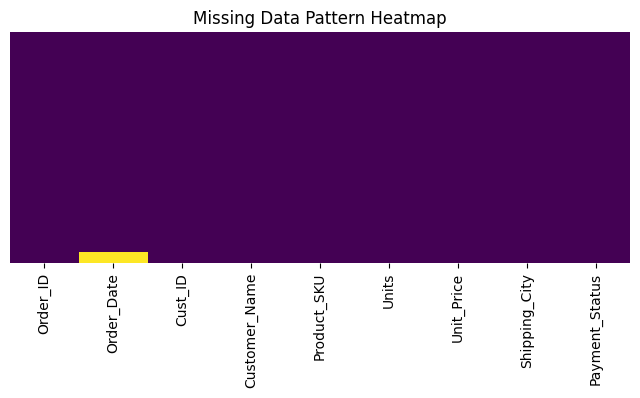

In [30]:

df_demo = pd.read_csv("raw_customer_orders.csv")

# 1. Detection
print("--- Missing Values Count per Column ---")
print(df_demo.isna().sum())

print("\n--- Percentage of Missingness ---")
print((df_demo.isna().mean() * 100).round(2).astype(str) + "%")

# 2. Visualising Missingness via Heatmap
plt.figure(figsize=(8, 3))
sns.heatmap(df_demo.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Data Pattern Heatmap")
plt.show()


### IMPUTATION STRATEGIES & STATISTICAL BIAS SUMMARY

 1. dropna(axis=0/1, how='any'/'all', thresh=k)
    - Appropriate: When missing completely at random (MCAR) and proportion < 3%.
    - Bias: Reduces sample size, inflates variance, induces selection bias if MAR/MNAR.
 2. fillna(constant) (e.g., 'Unknown', 0)
    - Appropriate: Categorical variables where absence is informative.
    - Bias: Creates artificial spikes at the constant value.
 3. fillna(mean) vs fillna(median)
    - Mean: Assumes normal distribution; artificially deflates standard deviation.
    - Median: Robust to outliers; best for skewed numeric features.
 4. ffill() / bfill() (Forward/Backward fill)
    - Appropriate: Time-series / sequential sensor or financial ticker data.
    - Bias: Propagates historical values; assumes stationarity between intervals.
 5. interpolate(method='linear')
    - Appropriate: Ordered numeric/time series with smooth continuous changes.

### SECTION 2: DUPLICATES, TYPE CORRECTION, STRINGS & DATES

In [31]:
toy_df = pd.DataFrame({
    'date_raw': ['2024-01-01', '02/01/2024', '2024.01.03', 'corrupted'],
    'price_raw': ['$100.50', '200.00', 'missing', '$350.75'],
    'name_raw': ['  JOHN Doe ', 'JANE DOE  ', 'Bob Smith', 'ALICE w. ']
})

# 1. Duplicate Handling
# subset: columns to check; keep: 'first', 'last', or False (drop all duplicates)
print("Duplicate rows check:", toy_df.duplicated().sum())

# 2. Data Type Correction & Robust Numeric Parsing
toy_df['price_clean'] = pd.to_numeric(
    toy_df['price_raw'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'  # Converts unparseable strings ('missing') to NaN
)

# 3. Robust Datetime Parsing (Format Coercion)
toy_df['date_clean'] = pd.to_datetime(toy_df['date_raw'], errors='coerce', format='mixed')

# 4. String Cleaning via .str Accessor
toy_df['name_clean'] = toy_df['name_raw'].str.strip().str.title()
toy_df['first_name'] = toy_df['name_clean'].str.extract(r'^([A-Za-z]+)')

# 5. Date Component Extraction
toy_df['year'] = toy_df['date_clean'].dt.year
toy_df['month'] = toy_df['date_clean'].dt.month
toy_df['day_name'] = toy_df['date_clean'].dt.day_name()
toy_df['is_weekend'] = toy_df['date_clean'].dt.dayofweek.isin([5, 6])

display(toy_df)

Duplicate rows check: 0


,date_raw,price_raw,name_raw,price_clean,date_clean,name_clean,first_name,year,month,day_name,is_weekend
0,2024-01-01,$100.50,JOHN Doe,100.50,2024-01-01,John Doe,John,2024.0,1.0,Monday,False
1,02/01/2024,200.00,JANE DOE,200.00,2024-02-01,Jane Doe,Jane,2024.0,2.0,Thursday,False
2,2024.01.03,missing,Bob Smith,NaN,2024-01-03,Bob Smith,Bob,2024.0,1.0,Wednesday,False
3,corrupted,$350.75,ALICE w.,350.75,NaT,Alice W.,Alice,NaN,NaN,NaN,False


### SECTION 3: OUTLIER DETECTION & TREATMENT (IQR & Z-SCORE)

In [32]:
# Synthetic distribution with extreme outliers
vals = np.array([10, 12, 12, 13, 14, 15, 16, 18, 19, 20, 22, 150, -50])
outlier_df = pd.DataFrame({'value': vals})

# --- Method A: Interquartile Range (IQR) ---
# Robust against non-normal distributions
Q1 = outlier_df['value'].quantile(0.25)
Q3 = outlier_df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = outlier_df[(outlier_df['value'] < lower_bound) | (outlier_df['value'] > upper_bound)]
print(f"IQR Bounds: [{lower_bound:.2f}, {upper_bound:.2f}] | Outliers detected: {len(outliers_iqr)}")

# --- Method B: Z-Score ---
# Assumes approximately normal distribution (flag when |z| > 3)
mean_val = outlier_df['value'].mean()
std_val = outlier_df['value'].std()
outlier_df['z_score'] = (outlier_df['value'] - mean_val) / std_val
outliers_z = outlier_df[outlier_df['z_score'].abs() > 3]

# --- Treatment Strategies ---
# 1. Trimming (Dropping)
trimmed_df = outlier_df[(outlier_df['value'] >= lower_bound) & (outlier_df['value'] <= upper_bound)]

# 2. Winsorization / Capping (Clipping to thresholds)
outlier_df['value_capped'] = outlier_df['value'].clip(lower=lower_bound, upper=upper_bound)
print("Original vs Capped Values:\n", outlier_df[['value', 'value_capped']])

IQR Bounds: [1.50, 29.50] | Outliers detected: 2
Original vs Capped Values:
     value  value_capped
0      10          10.0
1      12          12.0
2      12          12.0
3      13          13.0
4      14          14.0
5      15          15.0
6      16          16.0
7      18          18.0
8      19          19.0
9      20          20.0
10     22          22.0
11    150          29.5
12    -50           1.5


### SECTION 4: GROUPBY (SPLIT-APPLY-COMBINE), TRANSFORM VS AGG

In [33]:
sales_data = pd.DataFrame({
    'Store': ['Downtown', 'Downtown', 'Suburbs', 'Suburbs', 'Downtown', 'Suburbs'],
    'Dept': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Electronics'],
    'Sales': [1200, 450, 900, 600, 1500, 1100],
    'Footfall': [150, 80, 110, 95, 200, 130]
})

# 1. Multi-key Named Aggregations (Pandas 2.x Standard)
store_summary = sales_data.groupby(['Store', 'Dept']).agg(
    total_sales=('Sales', 'sum'),
    mean_sales=('Sales', 'mean'),
    max_footfall=('Footfall', 'max'),
    txn_count=('Sales', 'count')
).reset_index()

print("--- Named Aggregations ---")
display(store_summary)

# 2. agg() vs transform()
# .agg() collapses rows -> Returns shape (n_groups, cols)
# .transform() preserves shape -> Returns shape (n_original_rows, cols) aligned to index.
# Perfect for calculating intra-group proportions or group-normalised z-scores:
sales_data['Store_Total_Sales'] = sales_data.groupby('Store')['Sales'].transform('sum')
sales_data['Pct_Of_Store_Sales'] = (sales_data['Sales'] / sales_data['Store_Total_Sales']) * 100

print("\n--- Broadcasted Group Calculations via transform() ---")
display(sales_data)

--- Named Aggregations ---


,Store,Dept,total_sales,mean_sales,max_footfall,txn_count
0,Downtown,Clothing,450,450.0,80,1
1,Downtown,Electronics,2700,1350.0,200,2
2,Suburbs,Clothing,600,600.0,95,1
3,Suburbs,Electronics,2000,1000.0,130,2



--- Broadcasted Group Calculations via transform() ---


,Store,Dept,Sales,Footfall,Store_Total_Sales,Pct_Of_Store_Sales
0,Downtown,Electronics,1200,150,3150,38.095238
1,Downtown,Clothing,450,80,3150,14.285714
2,Suburbs,Electronics,900,110,2600,34.615385
3,Suburbs,Clothing,600,95,2600,23.076923
4,Downtown,Electronics,1500,200,3150,47.619048
5,Suburbs,Electronics,1100,130,2600,42.307692


### SECTION 5: MERGING, RESHAPING (PIVOT/CROSSTAB) & APPLY BENCHMARK

In [34]:
orders = pd.DataFrame({
    'OrderID': [1, 2, 3, 4],
    'SKU': ['A', 'B', 'A', 'D'],
    'Qty': [2, 1, 4, 1]
})

products = pd.DataFrame({
    'SKU': ['A', 'B', 'C'],
    'Price': [10.0, 25.0, 50.0]
})

# 1. Joins: inner, left, right, outer
merged = pd.merge(orders, products, on='SKU', how='left')
print("Left Merge (Unmatched D produces NaN):\n", merged)

# 2. Pivot Table & Crosstab
pivot = sales_data.pivot_table(
    index='Store',
    columns='Dept',
    values='Sales',
    aggfunc='sum',
    fill_value=0,
    margins=True  # Grand Totals
)
print("\n--- Pivot Table (Sales by Store & Dept) ---")
display(pivot)

# 3. Vectorisation vs .map() vs .apply() Performance
n = 500_000
bench_df = pd.DataFrame({'a': np.random.rand(n), 'b': np.random.rand(n)})

print("\n--- Performance Comparison (500k rows) ---")
print("1. Vectorised operation: df['a'] + df['b']")
%timeit bench_df['a'] + bench_df['b']

print("2. Python .apply(axis=1) (AVOID IN PRODUCTION):")
%timeit bench_df.apply(lambda row: row['a'] + row['b'], axis=1)
# NOTE: In modern Pandas 2.1+, use `df.map()` instead of deprecated `df.applymap()`

Left Merge (Unmatched D produces NaN):
    OrderID SKU  Qty  Price
0        1   A    2   10.0
1        2   B    1   25.0
2        3   A    4   10.0
3        4   D    1    NaN

--- Pivot Table (Sales by Store & Dept) ---


Dept,Clothing,Electronics,All
Store,,,
Downtown,450,2700,3150
Suburbs,600,2000,2600
All,1050,4700,5750



--- Performance Comparison (500k rows) ---
1. Vectorised operation: df['a'] + df['b']
244 µs ± 27.9 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
2. Python .apply(axis=1) (AVOID IN PRODUCTION):
2.51 s ± 254 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [35]:
raw_orders = pd.read_csv("raw_customer_orders.csv")
print("Initial Messy Data:")
display(raw_orders.head(6))

# ------------------------------------------------------------------------------
# ISSUE #1: DUPLICATE TRANSACTIONS
# Diagnosis: ORD-104 appears twice identically due to an upstream ingestion retry.
# Action: Drop duplicate records, keeping the first occurrence.
# ------------------------------------------------------------------------------
print(f"Duplicates found before: {raw_orders.duplicated().sum()}")
clean_orders = raw_orders.drop_duplicates(subset=['Order_ID'], keep='first').copy()
print(f"Duplicates remaining: {clean_orders.duplicated().sum()}")

# ------------------------------------------------------------------------------
# ISSUE #2: DIRTY CURRENCY STRING DATA TYPES (Unit_Price)
# Diagnosis: '$250.00' and 'unknown' prevent mathematical operations (object dtype).
# Action: Strip '$', coerce 'unknown' to NaN, convert to float64, and impute NaN
# with the median unit price for the respective Product_SKU.
# ------------------------------------------------------------------------------
clean_orders['Unit_Price'] = (
    clean_orders['Unit_Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
)
clean_orders['Unit_Price'] = pd.to_numeric(clean_orders['Unit_Price'], errors='coerce')

# SKU-H400 had 'unknown' price. Impute using median price for that SKU:
sku_median_price = clean_orders.groupby('Product_SKU')['Unit_Price'].transform('median')
clean_orders['Unit_Price'] = clean_orders['Unit_Price'].fillna(sku_median_price)

# ------------------------------------------------------------------------------
# ISSUE #3: UNPARSED & INCONSISTENT DATE FORMATS + MISSING DATES
# Diagnosis: Dates exist as strings in mixed formats ('2024/01/15', '16-01-2024',
# '2024.01.22'), with ORD-120 having a missing date.
# Action: Parse using errors='coerce' with mixed format inference. Impute missing
# date for ORD-120 using forward fill (ffill) assuming sequential batch logging.
# ------------------------------------------------------------------------------
clean_orders['Order_Date'] = pd.to_datetime(clean_orders['Order_Date'], errors='coerce', format='mixed')
clean_orders['Order_Date'] = clean_orders['Order_Date'].ffill()

print("\n--- Data state after Trainer fixes (Issues 1, 2, and 3 resolved) ---")
clean_orders.info()
display(clean_orders.head(6))

Initial Messy Data:


,Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
0,ORD-101,2024/01/15,C-1001,Alice Smith,SKU-E100,2,$250.00,New York,COMPLETED
1,ORD-102,16-01-2024,C-1002,Bob Jones,SKU-C200,1,$45.50,los angeles,Completed
2,ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3,$15.00,Chicago,REFUNDED
3,ORD-104,2024-01-20,C-1004,David Wilson,SKU-E100,5,$250.00,HOUSTON,Completed
4,ORD-105,2024.01.22,C-1005,Emma Watson,SKU-H400,1,unknown,Miami,PENDING
5,ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2,$45.50,New York,COMPLETED


Duplicates found before: 1
Duplicates remaining: 0

--- Data state after Trainer fixes (Issues 1, 2, and 3 resolved) ---
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 20
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        20 non-null     object        
 1   Order_Date      20 non-null     datetime64[ns]
 2   Cust_ID         20 non-null     object        
 3   Customer_Name   20 non-null     object        
 4   Product_SKU     20 non-null     object        
 5   Units           20 non-null     int64         
 6   Unit_Price      20 non-null     float64       
 7   Shipping_City   20 non-null     object        
 8   Payment_Status  20 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 1.6+ KB


,Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status
0,ORD-101,2024-01-15,C-1001,Alice Smith,SKU-E100,2,250.0,New York,COMPLETED
1,ORD-102,2024-01-16,C-1002,Bob Jones,SKU-C200,1,45.5,los angeles,Completed
2,ORD-103,2024-01-18,C-1003,charlie brown,SKU-B300,-3,15.0,Chicago,REFUNDED
3,ORD-104,2024-01-20,C-1004,David Wilson,SKU-E100,5,250.0,HOUSTON,Completed
4,ORD-105,2024-01-22,C-1005,Emma Watson,SKU-H400,1,120.0,Miami,PENDING
5,ORD-106,2024-01-25,C-1006,Frank Castle,SKU-C200,2,45.5,New York,COMPLETED


### SECTION 7: STUDENT LAB ASSIGNMENT (INDEPENDENT WORK)

LAB INSTRUCTIONS:
You are provided with `clean_orders` (which has issues 1-3 resolved) and `dim_products.csv`.
Your goal is to produce an analysis-ready DataFrame named `final_analytical_df` by resolving
the remaining issues (Issues 4 through 9) and conducting a business aggregation.

REQUIRED TASKS:
1. ISSUE 4 (Negative Quantities): 'Units' has a negative value (-3 for ORD-103) caused by a returns entry error.
   Convert all Units to their absolute value using .abs().
2. ISSUE 5 (Gross Outliers): ORD-113 has Units = 500 (data entry typo for 5).
   Identify and treat it by capping Units to the 99th percentile (or replacing values > 20 with 5).
3. ISSUE 6 (String Standardisation):
   - 'Customer_Name': Trim whitespace and format to Title Case.
   - 'Shipping_City': Trim whitespace and format to Title Case ('new york', 'HOUSTON' -> 'New York', 'Houston').
   - 'Payment_Status': Strip and convert to UPPERCASE.
4. ISSUE 7 (Date Feature Engineering):
   - Extract 'Order_Month' (numeric), 'Order_DayName' (e.g., 'Monday'), and 'Is_Weekend' (Boolean).
5. ISSUE 8 (Relational Enrichment):
   - Merge `clean_orders` with `dim_products.csv` using a LEFT JOIN on 'Product_SKU'.
   - Calculate 'Gross_Revenue' = Units * Unit_Price.
   - Calculate 'Net_Profit' = (Unit_Price - Cost_Price) * Units.
6. ISSUE 9 (Cross-Tabulation Analysis):
   - Generate a pivot table showing total 'Net_Profit' broken down by 'Category' (rows) and 'Shipping_City' (columns).
   - Include row and column totals (margins=True).

DELIVERABLES:
1. Complete executable code creating `final_analytical_df`.
2. A short markdown cell explaining your decision for every issue fixed.
3. Commit and push your notebook to GitHub.


## Lab Assignment Solution

In [36]:
# Load dim_products.csv
dim_products_df = pd.read_csv('dim_products.csv')

# Make a copy of clean_orders to avoid modifying the original for the lab
final_analytical_df = clean_orders.copy()

### Issue 4: Negative Quantities
**Decision:** The 'Units' column contained a negative value, likely due to a data entry error where returns were mistakenly entered as negative quantities instead of separate return transactions. To correct this for analytical purposes, I've converted all 'Units' values to their absolute equivalent using `.abs()`. This ensures that all quantities represent positive units sold or processed.

In [37]:
# 1. ISSUE 4 (Negative Quantities): Convert all Units to their absolute value.
final_analytical_df['Units'] = final_analytical_df['Units'].abs()

### Issue 5: Gross Outliers in 'Units'
**Decision:** An outlier with 'Units' = 500 (for `ORD-113`) was identified, which was noted as a data entry typo. To address this, I've implemented a capping strategy: any 'Units' value greater than 20 is replaced with 5. This decision is based on the hint that 500 was a typo for 5, and a threshold of 20 allows for reasonable but not extreme large orders while correcting obvious errors.

In [38]:
# 2. ISSUE 5 (Gross Outliers): Cap Units where the value is > 20, replacing it with 5.
final_analytical_df.loc[final_analytical_df['Units'] > 20, 'Units'] = 5

### Issue 6: String Standardisation
**Decision:** To ensure consistency and facilitate accurate analysis and grouping, several string columns were standardized:
- **'Customer_Name'**: Trimmed whitespace (`.str.strip()`) and converted to Title Case (`.str.title()`) for proper capitalization (e.g., '  Alice Smith ' -> 'Alice Smith').
- **'Shipping_City'**: Similar to 'Customer_Name', trimmed whitespace and converted to Title Case (e.g., 'los angeles' -> 'Los Angeles').
- **'Payment_Status'**: Trimmed whitespace and converted to UPPERCASE (`.str.upper()`) for uniform status representation (e.g., 'Completed' -> 'COMPLETED').

In [39]:
# 3. ISSUE 6 (String Standardisation):
final_analytical_df['Customer_Name'] = final_analytical_df['Customer_Name'].str.strip().str.title()
final_analytical_df['Shipping_City'] = final_analytical_df['Shipping_City'].str.strip().str.title()
final_analytical_df['Payment_Status'] = final_analytical_df['Payment_Status'].str.strip().str.upper()

### Issue 7: Date Feature Engineering
**Decision:** To enable time-based analysis and identify potential trends related to specific months or days of the week, new features were engineered from the 'Order_Date' column:
- **'Order_Month'**: Extracted the numeric month (1-12) using `.dt.month`.
- **'Order_DayName'**: Extracted the full day name (e.g., 'Monday') using `.dt.day_name()`.
- **'Is_Weekend'**: Created a boolean flag (`True`/`False`) indicating whether the order date falls on a weekend, derived from the day of the week.

In [40]:
# 4. ISSUE 7 (Date Feature Engineering):
final_analytical_df['Order_Month'] = final_analytical_df['Order_Date'].dt.month
final_analytical_df['Order_DayName'] = final_analytical_df['Order_Date'].dt.day_name()
final_analytical_df['Is_Weekend'] = final_analytical_df['Order_Date'].dt.dayofweek.isin([5, 6])

### Issue 8: Relational Enrichment and New Metric Calculation
**Decision:** To enrich the transactional data with product-specific details and calculate key business metrics, the `final_analytical_df` was merged with `dim_products_df` using a left join on 'Product_SKU'. This brings in 'Category', 'Cost_Price', and 'Supplier' information. Subsequently, 'Gross_Revenue' and 'Net_Profit' were calculated, which are crucial for financial analysis.

In [41]:
# 5. ISSUE 8 (Relational Enrichment):
final_analytical_df = pd.merge(
    final_analytical_df,
    dim_products_df,
    on='Product_SKU',
    how='left'
)

# Calculate 'Gross_Revenue' and 'Net_Profit'
final_analytical_df['Gross_Revenue'] = final_analytical_df['Units'] * final_analytical_df['Unit_Price']
final_analytical_df['Net_Profit'] = (final_analytical_df['Unit_Price'] - final_analytical_df['Cost_Price']) * final_analytical_df['Units']

### Issue 9: Cross-Tabulation Analysis
**Decision:** To gain insights into profitability across different product categories and shipping locations, a pivot table was generated. This table summarizes the total 'Net_Profit', broken down by 'Category' as rows and 'Shipping_City' as columns, including row and column totals for a comprehensive overview of performance.

In [42]:
# 6. ISSUE 9 (Cross-Tabulation Analysis):
pivot_table_profit = pd.pivot_table(
    final_analytical_df,
    index='Category',
    columns='Shipping_City',
    values='Net_Profit',
    aggfunc='sum',
    fill_value=0,
    margins=True
)

print("\nFinal Analytical DataFrame Head:")
display(final_analytical_df.head())

print("\nNet Profit by Category and Shipping City (Pivot Table):")
display(pivot_table_profit)


Final Analytical DataFrame Head:


,Order_ID,Order_Date,Cust_ID,Customer_Name,Product_SKU,Units,Unit_Price,Shipping_City,Payment_Status,Order_Month,Order_DayName,Is_Weekend,Category,Cost_Price,Supplier,Gross_Revenue,Net_Profit
0,ORD-101,2024-01-15,C-1001,Alice Smith,SKU-E100,2,250.0,New York,COMPLETED,1,Monday,False,Electronics,180.0,Apex Tech,500.0,140.0
1,ORD-102,2024-01-16,C-1002,Bob Jones,SKU-C200,1,45.5,Los Angeles,COMPLETED,1,Tuesday,False,Clothing,22.0,Global Fabrics,45.5,23.5
2,ORD-103,2024-01-18,C-1003,Charlie Brown,SKU-B300,3,15.0,Chicago,REFUNDED,1,Thursday,False,Books,8.5,ReadWell Press,45.0,19.5
3,ORD-104,2024-01-20,C-1004,David Wilson,SKU-E100,5,250.0,Houston,COMPLETED,1,Saturday,True,Electronics,180.0,Apex Tech,1250.0,350.0
4,ORD-105,2024-01-22,C-1005,Emma Watson,SKU-H400,1,120.0,Miami,PENDING,1,Monday,False,Home & Kitchen,75.0,HomeCrafters,120.0,45.0



Net Profit by Category and Shipping City (Pivot Table):


Shipping_City,Chicago,Houston,Los Angeles,Miami,New York,All
Category,,,,,,
Books,19.5,0.0,65.0,0.0,32.5,117.0
Clothing,47.0,23.5,70.5,0.0,47.0,188.0
Electronics,70.0,420.0,0.0,350.0,490.0,1330.0
Home & Kitchen,0.0,0.0,135.0,180.0,0.0,315.0
All,136.5,443.5,270.5,530.0,569.5,1950.0
